In [218]:
import pandas as pd
import numpy as np
import warnings
import seaborn as sns 
warnings.filterwarnings('ignore')

1. Надо увеличить число свечных паттернов до 5. Сделано
2. Надо усилить функцию, которая показывает первичную информацию о эффективности паттерна, думаю, что надо добавить фиусированный размер капитала и плясать от него уже. Сделано, добавил профит фактор. У нас сейчас 
3. Надо сделать первичный анализ и отобрать претендентов для ml. То есть, глянуть на количество сделок, общую эффективность паттерна, то есть, если он плохой, то лучше его не трогать.
4. Нужно добавить больше признаков для модели, придумать ещё хотя бы 20 чистых(индикаторы всякие, волатильность и прочее)
5. Сделать какой-то пайплайн для паттернов из 1, 2 или 3 свечей?

In [219]:
sber = pd.read_csv('data/SBRF.txt')

In [220]:
def good_dataframe(data, timeframe):
  """Преобразует сырые рыночные данные в чистый DataFrame с правильными типами и индексом времени
    
    Подготавливает данные для технического анализа.
    
    Args:
        data (pd.DataFrame): Исходный DataFrame с рыночными данными, содержащий столбцы:
            ['<TICKER>', '<PER>', '<DATE>', '<TIME>', '<OPEN>', '<HIGH>', '<LOW>', '<CLOSE>', '<VOL>']
            
    Returns:
        tuple: Возвращает кортеж из двух DataFrame:
            - Основной DataFrame
            - Копия DataFrame для безопасного резервирования
            
    Processing Logic:
        1. Удаление избыточных столбцов
        2. Переименование столбцов в human-friendly формат
        3. Преобразование типов данных
        4. Создание правильного временного индекса
    
    """
  # 1. Делаем копию, чтобы не изменялся исходный датафрейм
  data = data.copy()
  
  # 2. Переименовываем столбцы для удобства работы
  data.columns = ['ticker', 'per', 'date', 'time', 'open', 'high', 'low', 'close', 'volume']
    
  # 3. Преобразуем дату из формата YYYYMMDD в datetime
  data['date'] = pd.to_datetime(data['date'], format='%Y%m%d')
    
  # 4. Обрабатываем время (HHMMSS -> datetime.time)
  data['time'] = pd.to_datetime(data['time'], format='%H%M%S').dt.time
    
  # 5. Комбинируем дату и время в единую метку времени
  data['time'] = pd.to_datetime(
        data['date'].astype('str') + ' ' + data['time'].astype('str'))
    
  # 6. Удаляем отдельный столбец даты (теперь он в индексе)
  data.drop(['date'], inplace=True, axis=1)
  
  # 7. Установка индекса
  data_final = data.set_index('time')
  
  
  
  def new_timeframe(data, timeframe):
    """Преобразует минутные данные (1М) в указанный временной интервал, сохраняя структуру OHLCV-данных.
    
    Использует принципы агрегации свечных данных:
    - Open - первое значение периода
    - High - максимум периода
    - Low - минимум периода
    - Close - последнее значение периода
    - Volume - сумма объема за период

    Args:
        data (pd.DataFrame): Исходный DataFrame с 1-минутными данными, 
                            должен содержать колонки ['open', 'high', 'low', 'close', 'volume']
                            и иметь DateTimeIndex
        timeframe (str): Желаемый таймфрейм из списка доступных:
                        ['5 min', '15 min', '30 min', '1h', '2h', '4h', 'D']

    Returns:
        pd.DataFrame: Новый DataFrame с преобразованными данными в указанном таймфрейме
        
    Raises:
        ValueError: Если передан неподдерживаемый timeframe
    """

    dict_tf = {'5 min' : '5min', '15 min' : '15min', '30 min' : '30min',
               '1h' : '1h', '2h' : '2h', '4h' : '4h', 'D' : 'D'}

    return_data = data.resample(dict_tf[timeframe]).agg({
            'ticker': 'first',
            'per': 'first',
            'open': 'first',
            'high': 'max',
            'low': 'min',
            'close': 'last',
            'volume': 'sum'
        }).dropna()
    

    return_data['per'] = timeframe
    return return_data
  
  result = new_timeframe(data_final, timeframe)
  
  result = result.reset_index()
  
  return result


In [221]:
# def good_dataframe(data, timeframe):
#   """Преобразует сырые рыночные данные в чистый DataFrame с правильными типами и индексом времени
    
#     Подготавливает данные для технического анализа.
    
#     Args:
#         data (pd.DataFrame): Исходный DataFrame с рыночными данными, содержащий столбцы:
#             ['<TICKER>', '<PER>', '<DATE>', '<TIME>', '<OPEN>', '<HIGH>', '<LOW>', '<CLOSE>', '<VOL>']
            
#     Returns:
#         tuple: Возвращает кортеж из двух DataFrame:
#             - Основной DataFrame
#             - Копия DataFrame для безопасного резервирования
            
#     Processing Logic:
#         1. Удаление избыточных столбцов
#         2. Переименование столбцов в human-friendly формат
#         3. Преобразование типов данных
#         4. Создание правильного временного индекса
#     """
#   # 1. Удаляем ненужные столбцы (тикер и период не нужны для анализа)
#   data.drop(['<TICKER>', '<PER>'], inplace=True, axis=1)
    
#   # 2. Переименовываем столбцы для удобства работы
#   data.columns = ['date', 'time', 'open', 'high', 'low', 'close', 'volume']
    
#   # 3. Преобразуем дату из формата YYYYMMDD в datetime
#   data['date'] = pd.to_datetime(data['date'], format='%Y%m%d')
    
#   # 4. Обрабатываем время (HHMMSS -> datetime.time)
#   data['time'] = pd.to_datetime(data['time'], format='%H%M%S').dt.time
    
#   # 5. Комбинируем дату и время в единую метку времени
#   data['time'] = pd.to_datetime(
#         data['date'].astype('str') + ' ' + data['time'].astype('str'))
    
#   # 6. Удаляем отдельный столбец даты (теперь он в индексе)
#   data.drop(['date'], inplace=True, axis=1)
  
#   # 7. Установка индекса
#   data_final = data.set_index('time')
  
  
  
#   def new_timeframe(data, timeframe):
#     """Преобразует минутные данные (1М) в указанный временной интервал, сохраняя структуру OHLCV-данных.
    
#     Использует принципы агрегации свечных данных:
#     - Open - первое значение периода
#     - High - максимум периода
#     - Low - минимум периода
#     - Close - последнее значение периода
#     - Volume - сумма объема за период

#     Args:
#         data (pd.DataFrame): Исходный DataFrame с 1-минутными данными, 
#                             должен содержать колонки ['open', 'high', 'low', 'close', 'volume']
#                             и иметь DateTimeIndex
#         timeframe (str): Желаемый таймфрейм из списка доступных:
#                         ['5 min', '15 min', '30 min', '1h', '2h', '4h', 'D']

#     Returns:
#         pd.DataFrame: Новый DataFrame с преобразованными данными в указанном таймфрейме
        
#     Raises:
#         ValueError: Если передан неподдерживаемый timeframe
#     """
#     dict_tf = {'5 min' : '5min', '15 min' : '15min', '30 min' : '30min',
#                '1h' : '1h', '2h' : '2h', '4h' : '4h', 'D' : 'D'}

#     return_data = data.resample(dict_tf[timeframe]).agg({
#             'open': 'first',
#             'high': 'max',
#             'low': 'min',
#             'close': 'last',
#             'volume': 'sum'
#         }).dropna()
    
#     return return_data
  
#   result_bad = new_timeframe(data_final, timeframe)
#   result = result_bad.reset_index()
#   return result


In [222]:
sber_15 = good_dataframe(sber, '5 min')
sber_15

,time,ticker,per,open,high,low,close,volume
0,2009-01-11 10:30:00,SBRF,5 min,2301.0,2346.0,2265.0,2334.0,769
1,2009-01-11 10:35:00,SBRF,5 min,2334.0,2338.0,2320.0,2327.0,399
2,2009-01-11 10:40:00,SBRF,5 min,2322.0,2341.0,2322.0,2340.0,1825
3,2009-01-11 10:45:00,SBRF,5 min,2341.0,2355.0,2340.0,2350.0,2444
4,2009-01-11 10:50:00,SBRF,5 min,2350.0,2376.0,2349.0,2370.0,1614
...,...,...,...,...,...,...,...,...
675268,2025-06-30 23:25:00,SBRF,5 min,29865.0,29865.0,29847.0,29849.0,23
675269,2025-06-30 23:30:00,SBRF,5 min,29849.0,29853.0,29849.0,29849.0,51
675270,2025-06-30 23:35:00,SBRF,5 min,29849.0,29849.0,29846.0,29846.0,23
675271,2025-06-30 23:40:00,SBRF,5 min,29846.0,29851.0,29845.0,29845.0,92


# Смещение данных

In [223]:
def shift_features_2_candle(data):
    data_c = data.copy()
    for i in ['open', 'close', 'low', 'high', 'volume', 'time']:
        data_c[f"{i}_N"] = data[i]
        data_c[f'{i}_N-1'] = data[i].shift(1)
    data_c.drop(['open', 'close', 'low', 'high', 'volume', 'time'], axis=1, inplace=True)
    data_c.dropna(inplace=True)
    for i in ['open', 'close', 'low', 'high', 'volume']:
        data_c[f'{i}_N-1'] = data_c[f'{i}_N-1'].astype('int32')
    return data_c

df = shift_features_2_candle(sber_15)
df

,ticker,per,open_N,open_N-1,close_N,close_N-1,low_N,low_N-1,high_N,high_N-1,volume_N,volume_N-1,time_N,time_N-1
1,SBRF,5 min,2334.0,2301,2327.0,2334,2320.0,2265,2338.0,2346,399,769,2009-01-11 10:35:00,2009-01-11 10:30:00
2,SBRF,5 min,2322.0,2334,2340.0,2327,2322.0,2320,2341.0,2338,1825,399,2009-01-11 10:40:00,2009-01-11 10:35:00
3,SBRF,5 min,2341.0,2322,2350.0,2340,2340.0,2322,2355.0,2341,2444,1825,2009-01-11 10:45:00,2009-01-11 10:40:00
4,SBRF,5 min,2350.0,2341,2370.0,2350,2349.0,2340,2376.0,2355,1614,2444,2009-01-11 10:50:00,2009-01-11 10:45:00
5,SBRF,5 min,2371.0,2350,2361.0,2370,2355.0,2349,2380.0,2376,746,1614,2009-01-11 10:55:00,2009-01-11 10:50:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
675268,SBRF,5 min,29865.0,29850,29849.0,29865,29847.0,29842,29865.0,29865,23,156,2025-06-30 23:25:00,2025-06-30 23:20:00
675269,SBRF,5 min,29849.0,29865,29849.0,29849,29849.0,29847,29853.0,29865,51,23,2025-06-30 23:30:00,2025-06-30 23:25:00
675270,SBRF,5 min,29849.0,29849,29846.0,29849,29846.0,29849,29849.0,29853,23,51,2025-06-30 23:35:00,2025-06-30 23:30:00
675271,SBRF,5 min,29846.0,29849,29845.0,29846,29845.0,29846,29851.0,29849,92,23,2025-06-30 23:40:00,2025-06-30 23:35:00


# Напишем функцию детекции свечного паттерна

In [224]:
def detection_bullish_engulfing_pattern(data):
    """
    Функция для детекции бычьего паттерна 'поглощение' (Bullish Engulfing) на ценовых данных."""

    data = data.copy()
    data['pattern'] = 0
    data['signal'] = 0
    data['strategy'] = 'bullish_engulfing_pattern'
    
    # Векторизованные вычисления
    close_N = data['close_N']
    close_N_1 = data['close_N-1']
    open_N = data['open_N']
    open_N_1 = data['open_N-1']
    
    body_N = data['close_N'] - data['open_N']
    body_N_1 = data['close_N-1'] - data['open_N-1']
    
    # Базовое условие бычьего поглощения
    base_condition = (
        (body_N_1 < 0) & 
        (body_N > 0) &
        (open_N_1 < close_N) & 
        (close_N_1 > open_N)
    )
    
    # Отмечаем 2 свечи паттерна
    pattern_mask = base_condition
    data.loc[pattern_mask, 'pattern'] = 1
    # Сигнал - следующая свеча после завершения паттерна
    data.loc[pattern_mask.shift(1).fillna(False), 'signal'] = 1
    
    return data

In [225]:
def detection_bullish_harami_pattern(data):
    """
    Функция для детекции бычьего паттерна 'харами' (Bullish Harami) на ценовых данныx.
    Паттерн Харами состоит из большой медвежьей свечи, за которой следует маленькая бычья свеча,
    полностью содержащаяся в пределах тела предыдущей свечи.
    """
    data = data.copy()
    data['pattern'] = 0
    data['signal'] = 0
    data['strategy'] = 'bullish_engulfing_pattern'
    
    # Векторизованные вычисления
    close_N = data['close_N']
    close_N_1 = data['close_N-1']
    open_N = data['open_N']
    open_N_1 = data['open_N-1']
    
    body_N = data['close_N'] - data['open_N']
    body_N_1 = data['close_N-1'] - data['open_N-1']
    
    # Базовое условие для бычьего харами
    base_condition = (
        (body_N_1 < 0) & 
        (body_N > 0) &
        (close_N_1 < open_N) & 
        (open_N_1 > close_N))
    
    # Отмечаем 2 свечи паттерна
    pattern_mask = base_condition
    data.loc[pattern_mask, 'pattern'] = 1
    # Сигнал - следующая свеча после завершения паттерна
    data.loc[pattern_mask.shift(1).fillna(False), 'signal'] = 1
        
    
    return data

In [226]:
def detection_break_in_the_clouds(data):
    """Первая свеча падающая, вторая растущая, открытие второй свечи ниже закрытия первой. перекрытия нет.
    """
    data = data.copy()
    data['pattern'] = 0
    data['signal'] = 0
    data['strategy'] = 'break_in_the_clouds'
    
    # Векторизованные вычисления
    close_N = data['close_N']
    close_N_1 = data['close_N-1']
    open_N = data['open_N']
    open_N_1 = data['open_N-1']
    
    body_N = data['close_N'] - data['open_N']
    body_N_1 = data['close_N-1'] - data['open_N-1']
    
    # Базовое условие для просвета в облаках
    base_condition = (
        (body_N_1 < 0) & 
        (body_N > 0) &
        (open_N < close_N_1) & 
        (close_N < open_N_1))
    
    # Отмечаем 2 свечи паттерна
    pattern_mask = base_condition
    data.loc[pattern_mask, 'pattern'] = 1
    # Сигнал - следующая свеча после завершения паттерна
    data.loc[pattern_mask.shift(1).fillna(False), 'signal'] = 1
        
    
    return data

In [227]:
df_b = detection_bullish_engulfing_pattern(df)

In [228]:
df_b.head()

,ticker,per,open_N,open_N-1,close_N,close_N-1,low_N,low_N-1,high_N,high_N-1,volume_N,volume_N-1,time_N,time_N-1,pattern,signal,strategy
1,SBRF,5 min,2334.0,2301,2327.0,2334,2320.0,2265,2338.0,2346,399,769,2009-01-11 10:35:00,2009-01-11 10:30:00,0,0,bullish_engulfing_pattern
2,SBRF,5 min,2322.0,2334,2340.0,2327,2322.0,2320,2341.0,2338,1825,399,2009-01-11 10:40:00,2009-01-11 10:35:00,1,0,bullish_engulfing_pattern
3,SBRF,5 min,2341.0,2322,2350.0,2340,2340.0,2322,2355.0,2341,2444,1825,2009-01-11 10:45:00,2009-01-11 10:40:00,0,1,bullish_engulfing_pattern
4,SBRF,5 min,2350.0,2341,2370.0,2350,2349.0,2340,2376.0,2355,1614,2444,2009-01-11 10:50:00,2009-01-11 10:45:00,0,0,bullish_engulfing_pattern
5,SBRF,5 min,2371.0,2350,2361.0,2370,2355.0,2349,2380.0,2376,746,1614,2009-01-11 10:55:00,2009-01-11 10:50:00,0,0,bullish_engulfing_pattern


Напишем функцию, которая считает прибыль или убыток при входе на цене открытия после завершения паттерна, держит позицию N следующих свечей, где N пробегает [1, 2, ..., 10, 15, 20, ..., 50] и выходит на закрытии последней свечи.

In [244]:
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression
def lst_trade_statistics_bul(data, commission=0.001):
   data = data.reset_index(drop=True)
   # Удалим сперва все отметки паттерна и сигнала с последних 51 строки
   data.loc[len(data) - 51 : len(data), ['pattern', 'signal']] = 0
   # Проходимся циклом по периодам удержания позиции
   all_strategy = []
   for N in [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 15, 20, 25, 30, 35, 40, 45, 50]:
      strategy = [] # Список для результатов стратегии
      # Блок для определения цены входа и выхода
      exit_candidate = data['open_N'].shift(-N)
      is_entry = data['signal'] == 1
      entry_price = data['open_N'][is_entry]
      exit_price = exit_candidate[is_entry]
      capital = 100_000
      # Считаем результат
      profit_percent = (exit_price.values - entry_price.values) / entry_price.values
      capital_curve = capital * np.cumprod(1 + profit_percent)
      total_return = (np.prod(1 + profit_percent) - 1) * 100
      profit = exit_price - entry_price
      
      # Считаем прибыль стратегии купи и держи:
      first_buy = data.loc[1, 'close_N']
      last_sell = data.loc[len(data) - 51, 'close_N']
      BH_strategy = ((last_sell - first_buy) / first_buy) * 100
      alpha = total_return - BH_strategy
      
      if len(profit) == 0:
         strategy_name = data['strategy'][1]
         all_strategy.append({'strategy' : 0, 'ticker' : 0,
                           'period' : 0,'N': N, 'trades': 0, 'win_rate': 0.0, 
                           'total_profit': 0.0, 'results': 0,
                              'total_return' : 0, 'alpha' : 0, 'max_drawdown' : 0, 'r2' : 0})
         continue
      
      def calculate_relative_drawdown(lst):
      #   cumulative = np.cumsum(lst)
        running_max = np.maximum.accumulate(lst)
        drawdown = (running_max - lst) 
        return np.max(drawdown)
      # Чистая прибыль
      profit_net = np.where(profit >= 0, profit * (1 - commission), profit * (1 + commission))
      # Статистика
      # Названия
      strategy_name = data['strategy'][1]
      per = data['per'][1]
      ticker = data['ticker'][1]
      # Считаем R^2 линейной регрессии, построенной по графику дохода
      X = np.array(list(range(len(capital_curve)))).reshape(-1, 1)
      y = np.array(capital_curve)
      lin = LinearRegression()
      
      lin.fit(X, y)
      y_pred = lin.predict(X)
      r2 = metrics.r2_score(y, y_pred)
      all_strategy.append({'strategy' : strategy_name,
                           'ticker' : ticker,
                           'period' : per,
                           'N' : N,
                           'trades' : len(profit_net),
                           'win_rate' : np.round(np.mean(profit_net > 0), 2),
                           'total_profit' : np.round(np.sum(profit_net), 1),
                           'results' : profit_net,
                           'total_return' : np.round(total_return, 2), 'capital_curve' : capital_curve, 'alpha' : alpha,
                           'max_drawdown' : calculate_relative_drawdown(capital_curve), 'r2' : np.round(r2, 2)})
   return pd.DataFrame(all_strategy)

result = lst_trade_statistics_bul(df_b)

result

,strategy,ticker,period,N,trades,win_rate,total_profit,results,total_return,capital_curve,alpha,max_drawdown,r2
0,bullish_engulfing_pattern,SBRF,5 min,1,19601,0.46,-261.0,"[8.991, -4.004, 0.0, -4.004, -2.002, 1.998, 3....",23.96,"[100384.4510892781, 100213.8742819896, 100213....",-1151.597456,25255.437590,0.54
1,bullish_engulfing_pattern,SBRF,5 min,2,19601,0.46,-8278.4,"[29.97, -9.008999999999999, -3.002999999999999...",-22.25,"[101281.50363092696, 100894.27613191321, 10076...",-1197.808426,31890.125861,0.22
2,bullish_engulfing_pattern,SBRF,5 min,3,19601,0.47,-17782.4,"[24.975, -11.011, -9.008999999999999, 2.997, -...",-54.38,"[101067.91969243913, 100595.63969387635, 10020...",-1229.933429,62441.714562,0.68
3,bullish_engulfing_pattern,SBRF,5 min,4,19601,0.47,-17755.3,"[20.979, -5.004999999999999, -8.008, 2.997, -1...",-50.86,"[100897.05254164887, 100682.74274440663, 10033...",-1226.416631,52982.729165,0.39
4,bullish_engulfing_pattern,SBRF,5 min,5,19601,0.47,-18552.9,"[26.973, -9.008999999999999, -3.00299999999999...",-43.53,"[101153.35326783426, 100766.61572347976, 10063...",-1219.089861,65057.187898,0.59
5,bullish_engulfing_pattern,SBRF,5 min,6,19601,0.48,-20946.1,"[18.981, -5.004999999999999, 0.999, 5.994, -11...",-58.91,"[100811.61896625375, 100597.49063370012, 10064...",-1234.466720,75849.310870,0.82
6,bullish_engulfing_pattern,SBRF,5 min,7,19601,0.48,-24632.9,"[10.989, -4.004, 0.999, 10.989, -11.011, -12.0...",-70.01,"[100469.88466467321, 100299.16268563384, 10034...",-1245.561398,76307.408583,0.87
7,bullish_engulfing_pattern,SBRF,5 min,8,19601,0.48,-17313.4,"[-3.0029999999999997, -7.007, 0.999, 3.996, -1...",-58.49,"[99871.84963690731, 99574.86452753672, 99617.4...",-1234.046426,62048.415115,0.50
8,bullish_engulfing_pattern,SBRF,5 min,9,19601,0.49,-16024.5,"[1.998, -8.008, -1.001, 3.996, -12.01199999999...",-45.46,"[100085.43357539512, 99745.29616307432, 99702....",-1221.018319,58387.730189,0.08
9,bullish_engulfing_pattern,SBRF,5 min,10,19601,0.49,-18887.7,"[0.999, -11.011, -2.002, 3.996, -17.017, 6.993...",-54.88,"[100042.71678769756, 99575.22745691393, 99490....",-1230.439238,66782.025659,0.04


In [230]:
# import seaborn as sns
# import matplotlib.pyplot as plt
# for i in range(17):
#     fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

#     # Первый график (ваш существующий)
#     ax1.set_title(f'{i} - Кумулятивная сумма сделок')
#     cumsume = np.cumsum(result_strategy.loc[i, "results"])
#     sns.lineplot(x=range(len(cumsume)), y=cumsume, ax=ax1)
#     ax1.set_xlabel('Номер сделки')
#     ax1.set_ylabel('Кумулятивная прибыль')
#     ax1.grid(True)

#     # Второй график (добавьте нужный вам)
#     ax2.set_title(f'{i} - Ваш второй график')
#     # Здесь добавьте данные для второго графика
#     # Например:
#     sns.lineplot(result_strategy.loc[i, 'capital_curve'])
#     ax2.set_xlabel('Время/Сделки')
#     ax2.set_ylabel('Значение')
#     ax2.grid(True)

#     plt.tight_layout()
#     plt.show()
#     print(result_strategy.loc[i, 'drawdown'])

In [231]:
# def lst_trade_statistics_bul(data, commission=0.001):
#    # Удалим сперва все отметки паттерна и сигнала с последних 51 строки
#    data.loc[len(data) - 51 : len(data), ['pattern', 'signal']] = 0
#    # Проходимся циклом по периодам удержания позиции
#    all_strategy = []
#    for N in [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 15, 20, 25, 30, 35, 40, 45, 50]:
#       strategy = [] # Список для результатов стратегии
#       # Блок для определения цены входа и выхода
#       exit_candidate = data['open_N'].shift(-N)
#       is_entry = data['signal'] == 1
#       entry_price = data['open_N'][is_entry]
#       exit_price = exit_candidate[is_entry]
#       # Считаем результат
#       profit = exit_price - entry_price
#       if len(profit) == 0:
#          strategy_name = data['strategy'][1]
#          filtr = data['filtr'][1]
#          all_strategy.append({'strategy' : strategy_name, 'N': N, 'trades': 0, 'win_rate': 0.0, 'total_profit': 0.0, 'results': 0, 'Profit_factor': 0})
#          continue
#       # Чистая прибыль
#       profit_net = np.where(profit >= 0, profit * (1 - commission), profit * (1 + commission))
#       # Статистика
#       # Названия
#       strategy_name = data['strategy'][1]
      
#       all_strategy.append({'strategy' : strategy_name,
#                            'N' : N,
#                            'trades' : len(profit_net),
#                            'win_rate' : np.round(np.mean(profit_net > 0), 2),
#                            'total_profit' : np.round(np.sum(profit_net), 1),
#                            'results' : profit_net,
#                            'Profit_factor' : np.round(np.sum(np.array(profit_net[profit_net > 0])) / np.abs(np.sum(np.array(profit_net[profit_net < 0]))), 3)})
#    return all_strategy

# result = lst_trade_statistics_bul(df_b)
# result_strategy = pd.DataFrame(result)
# result_strategy

Отбираем наилучшие стратегии для дальнейшего анализа с помощью моделей машинного обучения

In [232]:
l = []
for i in ['5 min', '15 min', '30 min', '1h', '2h', '4h', 'D']:
    sber_tm = good_dataframe(sber, i)
    l.append(sber_tm)

In [245]:
all_strategy = []
for detec in [detection_bullish_engulfing_pattern, detection_bullish_harami_pattern, detection_break_in_the_clouds]:
    for i in l:
        detection_data = detec(shift_features_2_candle(i))
        final_result = lst_trade_statistics_bul(detection_data)
        all_strategy.append(final_result)
        
    

In [246]:
combined_df = pd.concat(all_strategy, ignore_index=True)
combined_df.sort_values(by='r2', ascending=False, inplace=True, ignore_index=True)


In [247]:
combined_df

,strategy,ticker,period,N,trades,win_rate,total_profit,results,total_return,capital_curve,alpha,max_drawdown,r2
0,break_in_the_clouds,SBRF,D,3,224,0.56,12426.3,"[186.813, 241.758, 442.557, 386.613, 54.945, -...",274.35,"[112190.35202086049, 122212.52447898094, 14038...",-1000.649162,8.302147e+04,0.91
1,bullish_engulfing_pattern,SBRF,30 min,2,4130,0.50,9356.9,"[-3.0029999999999997, -4.004, 9.99, -6.0059999...",115.90,"[99871.79487179487, 99700.63498341134, 100127....",-1043.694232,3.197137e+04,0.89
2,break_in_the_clouds,SBRF,2h,3,1411,0.51,7474.8,"[-21.020999999999997, 26.973, -112.112, -21.02...",142.79,"[99095.2175786299, 100293.95004933914, 95234.0...",-1020.784456,4.419462e+04,0.87
3,bullish_engulfing_pattern,SBRF,5 min,7,19601,0.48,-24632.9,"[10.989, -4.004, 0.999, 10.989, -11.011, -12.0...",-70.01,"[100469.88466467321, 100299.16268563384, 10034...",-1245.561398,7.630741e+04,0.87
4,break_in_the_clouds,SBRF,15 min,2,10770,0.50,-10381.2,"[3.996, 1.998, -3.0029999999999997, 14.985, 1....",-39.21,"[100170.50298380222, 100256.4125060868, 100128...",-1200.371155,6.110250e+04,0.87
...,...,...,...,...,...,...,...,...,...,...,...,...,...
373,bullish_engulfing_pattern,SBRF,2h,5,1054,0.50,4185.3,"[11.988, -28.028, -69.06899999999999, -20.0199...",8.43,"[100572.79236276851, 98917.27314692046, 94691....",-1155.143548,6.576351e+04,0.00
374,break_in_the_clouds,SBRF,30 min,45,5703,0.51,221.3,"[-27.026999999999997, -100.1, -202.20199999999...",30.87,"[98849.10485933504, 94622.97810177474, 85551.3...",-1128.721868,1.011662e+06,0.00
375,break_in_the_clouds,SBRF,30 min,50,5703,0.51,-1820.4,"[-36.035999999999994, -103.103, -206.206, -267...",62.69,"[98465.47314578005, 94129.45615817195, 84926.4...",-1096.903124,1.674210e+06,0.00
376,bullish_engulfing_pattern,SBRF,5 min,20,22935,0.51,3927.7,"[-28.028, -12.011999999999999, -1.001, -3.0029...",-37.49,"[98817.56756756756, 98311.45966709347, 98269.5...",-1213.046690,1.049979e+05,0.00


In [236]:
# import seaborn as sns
# import matplotlib.pyplot as plt
# for i in range(100):
#     fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

#     # Первый график (ваш существующий)
#     ax1.set_title(f'{i} - Кумулятивная сумма сделок')
#     cumsume = np.cumsum(combined_df.loc[i, "results"])
#     sns.lineplot(x=range(len(cumsume)), y=cumsume, ax=ax1)
#     ax1.set_xlabel('Номер сделки')
#     ax1.set_ylabel('Кумулятивная прибыль')
#     ax1.grid(True)

#     # Второй график (добавьте нужный вам)
#     ax2.set_title(f'{i} - Ваш второй график')
#     # Здесь добавьте данные для второго графика
#     # Например:
#     sns.lineplot(combined_df.loc[i, 'capital_curve'])
#     ax2.set_xlabel('Время/Сделки')
#     ax2.set_ylabel('Значение')
#     ax2.grid(True)

#     plt.tight_layout()
#     plt.show()
    

In [248]:
sber_30 = good_dataframe(sber, '30 min')
sber_bull_eng = detection_bullish_engulfing_pattern(shift_features_2_candle(sber_30))


In [249]:
profit_N_2 = combined_df.loc[1, 'results']
print(len(profit_N_2))

4130


In [250]:
print(sum(sber_bull_eng['pattern']))

4133


In [251]:
profit_N_2 = combined_df.loc[1, 'results']
sber_bull_eng['profit'] = 0
pattern_indices = sber_bull_eng[sber_bull_eng['pattern'] == 1].index

# Берем последние 3 индекса и удаляем их
last_three_indices = pattern_indices[-3:]
sber_bull_eng = sber_bull_eng.drop(last_three_indices)
sber_bull_eng.loc[sber_bull_eng['pattern'] == 1, 'profit'] = profit_N_2


In [253]:
sber_bull_eng.head(20)

,ticker,per,open_N,open_N-1,close_N,close_N-1,low_N,low_N-1,high_N,high_N-1,volume_N,volume_N-1,time_N,time_N-1,pattern,signal,strategy,profit
1,SBRF,30 min,2366.0,2301,2347.0,2361,2324.0,2265,2369.0,2380,4471,7797,2009-01-11 11:00:00,2009-01-11 10:30:00,0,0,bullish_engulfing_pattern,0.000
2,SBRF,30 min,2343.0,2366,2346.0,2347,2338.0,2324,2355.0,2369,1198,4471,2009-01-11 11:30:00,2009-01-11 11:00:00,0,0,bullish_engulfing_pattern,0.000
3,SBRF,30 min,2346.0,2343,2339.0,2346,2339.0,2338,2354.0,2355,1420,1198,2009-01-11 12:00:00,2009-01-11 11:30:00,0,0,bullish_engulfing_pattern,0.000
4,SBRF,30 min,2340.0,2346,2339.0,2339,2328.0,2339,2344.0,2354,844,1420,2009-01-11 12:30:00,2009-01-11 12:00:00,0,0,bullish_engulfing_pattern,0.000
5,SBRF,30 min,2335.0,2340,2341.0,2339,2330.0,2328,2346.0,2344,734,844,2009-01-11 13:00:00,2009-01-11 12:30:00,1,0,bullish_engulfing_pattern,-3.003
6,SBRF,30 min,2340.0,2335,2338.0,2341,2338.0,2330,2345.0,2346,142,734,2009-01-11 13:30:00,2009-01-11 13:00:00,0,1,bullish_engulfing_pattern,0.000
7,SBRF,30 min,2339.0,2340,2342.0,2338,2333.0,2338,2342.0,2345,157,142,2009-01-11 14:00:00,2009-01-11 13:30:00,0,0,bullish_engulfing_pattern,0.000
8,SBRF,30 min,2337.0,2339,2334.0,2342,2334.0,2333,2342.0,2342,703,157,2009-01-11 14:30:00,2009-01-11 14:00:00,0,0,bullish_engulfing_pattern,0.000
9,SBRF,30 min,2334.0,2337,2323.0,2334,2319.0,2334,2335.0,2342,904,703,2009-01-11 15:00:00,2009-01-11 14:30:00,0,0,bullish_engulfing_pattern,0.000
10,SBRF,30 min,2323.0,2334,2320.0,2323,2320.0,2319,2327.0,2335,624,904,2009-01-11 15:30:00,2009-01-11 15:00:00,0,0,bullish_engulfing_pattern,0.000


Теперь нам необходимо создать признаки для модели классификации

# Создадим много относительных признаков

In [254]:
# Признаки по дате и времени
def data_time_features(data):
    # Для текущей свечи
    data = data.copy()
    data['time_N'] = pd.to_datetime(data['time_N'])
    data['months_N'] = data['time_N'].dt.month
    data['days_N'] = data['time_N'].dt.day
    data['hours_N'] = data['time_N'].dt.hour
    
    # Для предыдущей свечи
    data['time_N-1'] = pd.to_datetime(data['time_N-1'])
    data['months_N-1'] = data['time_N-1'].dt.month
    data['days_N-1'] = data['time_N-1'].dt.day
    data['hours_N-1'] = data['time_N-1'].dt.hour
    
    return data

In [255]:
# Признаки по каждой свече
def data_one_candle_features_1(data):
    # Для текущей свечи
    data = data.copy()
    
    # Отношение тела свечи ко всей свече
    body_N = np.abs(data['close_N'] - data['open_N'])
    body_N_1 = np.abs(data['close_N-1'] - data['open_N-1'])
    
    full_candle_N = np.abs(data['high_N'] - data['low_N'])
    full_candle_N_1 = np.abs(data['high_N-1'] - data['low_N-1'])
    
    data['ratio_body_to_all_candle_N'] = body_N / full_candle_N
    data['ratio_body_to_all_candle_N-1'] = body_N_1 / full_candle_N_1
    
    data = data.replace([np.inf], np.nan)
    data = data.fillna(1)
    
    # Отношение верхней тени к телу свечи
    up_shadow_N = np.where(data['close_N'] - data['open_N'] > 0, data['high_N'] - data['close_N'], data['high_N'] - data['open_N'])
    up_shadow_N_1 = np.where(data['close_N-1'] - data['open_N-1'] > 0, data['high_N-1'] - data['close_N-1'], data['high_N-1'] - data['open_N-1'])
    
    data['ratio_up_shadow_to_body_N'] = up_shadow_N / body_N
    data['ratio_up_shadow_to_body_N-1'] = up_shadow_N_1 / body_N_1
    
    data = data.replace([np.inf], np.nan)
    data = data.fillna(-1)
    
    # Отношение нижней тени к телу свечи
    low_shadow_N = np.where(data['close_N'] - data['open_N'] > 0, data['open_N'] - data['low_N'], data['close_N'] - data['low_N'])
    low_shadow_N_1 = np.where(data['close_N-1'] - data['open_N-1'] > 0, data['open_N-1'] - data['low_N-1'], data['close_N-1'] - data['low_N-1'])
    
    data['ratio_low_shadow_to_body_N'] = low_shadow_N / body_N
    data['ratio_low_shadow_to_body_N-1'] = low_shadow_N_1 / body_N_1
    
    data = data.replace([np.inf], np.nan)
    data = data.fillna(-1)
    
    # Отношение верхней тени к нижней тени
    data['ratio_up_shadow_to_low_shadow_N'] = up_shadow_N / low_shadow_N
    data['ratio_up_shadow_to_low_shadow_N-1'] = up_shadow_N_1 / low_shadow_N_1
    
    data = data.replace([np.inf], np.nan)
    data = data.fillna(-1)
    
    return data
    
    

In [256]:
def data_one_candle_features_2(data):
    data = data.copy()
    
    def ATR(data, period=14):
        high_low = data['high_N'] - data['low_N']
        high_close_prev = np.abs(data['high_N'] - data['close_N'].shift(1))
        low_close_prev = np.abs(data['low_N'] - data['close_N'].shift(1))
    
        TR = np.maximum(high_low, np.maximum(high_close_prev, low_close_prev))
        ATR = TR.rolling(period).mean()
    
        return ATR
    
    atr = ATR(data)
    
    data = data.copy()
    valid_mask = ~atr.isna()
    data = data[valid_mask]
    atr = atr[valid_mask]
    
    body_N = np.abs(data['close_N'] - data['open_N'])
    body_N_1 = np.abs(data['close_N-1'] - data['open_N-1'])
    
    full_candle_N = np.abs(data['high_N'] - data['low_N'])
    full_candle_N_1 = np.abs(data['high_N-1'] - data['low_N-1'])
    
    up_shadow_N = np.where(data['close_N'] - data['open_N'] > 0, data['high_N'] - data['close_N'], data['high_N'] - data['open_N'])
    up_shadow_N_1 = np.where(data['close_N-1'] - data['open_N-1'] > 0, data['high_N-1'] - data['close_N-1'], data['high_N-1'] - data['open_N-1'])
    
    low_shadow_N = np.where(data['close_N'] - data['open_N'] > 0, data['open_N'] - data['low_N'], data['close_N'] - data['low_N'])
    low_shadow_N_1 = np.where(data['close_N-1'] - data['open_N-1'] > 0, data['open_N-1'] - data['low_N-1'], data['close_N-1'] - data['low_N-1'])
    
    atr_safe = np.where(atr != 0, atr, 10e-8 )
    
    # Тело свечи / ATR
    data['body_ATR_N'] = body_N / atr_safe
    data['body_ATR_N-1'] = body_N_1 / atr_safe
    
    # Вся свеча / ATR
    data['full_candle_ATR_N'] = full_candle_N / atr_safe
    data['full_candle_ATR_N-1'] = full_candle_N_1 / atr_safe
    
    # Верхняя тень / ATR
    data['up_shadow_ATR_N'] = up_shadow_N / atr_safe
    data['up_shadow_ATR_N_1'] = up_shadow_N_1 / atr_safe
    
    # Нижняя тень / ATR
    data['low_shadow_ATR_N'] = low_shadow_N / atr_safe
    data['low_shadow_ATR_N_1'] = low_shadow_N_1 / atr_safe
    
    
    return data

In [257]:
def data_two_candles_features(data):
    data = data.copy()
    
    body_N = np.abs(data['close_N'] - data['open_N'])
    body_N_1 = np.abs(data['close_N-1'] - data['open_N-1'])
    
    full_candle_N = np.abs(data['high_N'] - data['low_N'])
    full_candle_N_1 = np.abs(data['high_N-1'] - data['low_N-1'])
    
    up_shadow_N = np.where(data['close_N'] - data['open_N'] > 0, data['high_N'] - data['close_N'], data['high_N'] - data['open_N'])
    up_shadow_N_1 = np.where(data['close_N-1'] - data['open_N-1'] > 0, data['high_N-1'] - data['close_N-1'], data['high_N-1'] - data['open_N-1'])
    
    low_shadow_N = np.where(data['close_N'] - data['open_N'] > 0, data['open_N'] - data['low_N'], data['close_N'] - data['low_N'])
    low_shadow_N_1 = np.where(data['close_N-1'] - data['open_N-1'] > 0, data['open_N-1'] - data['low_N-1'], data['close_N-1'] - data['low_N-1'])
    
    
    # Отношение: тело свечи N / тело свечи N-1
    data['body_N / body_N-1'] = body_N / body_N_1
    
    # Отношение вся свеча N / вся свеча N-1
    data['full candle N / full_candle_N-1'] = full_candle_N / full_candle_N_1
    
    # Отношение: вехней тени N / верхней тени N-1
    data['up_shadow_N / up_shadow_N-1'] =  up_shadow_N / up_shadow_N_1
    
    # Отношение: нижней тени N / нижней тени N-1
    data['low_shadow_N / low_shadow_N-1'] =  low_shadow_N / low_shadow_N_1
     
    return data
    
    

In [258]:
def indicators(data):
    data = data.copy()
    
    # RSI
    def rsi(prices, n=14):
        deltas = np.diff(prices)
        gains = np.where(deltas > 0, deltas, 0)
        loss = np.where(deltas < 0, -deltas, 0)
        
        # Расчитываем первые значения
        avg_gain = np.mean(gains[:n])
        avg_loss = np.mean(loss[:n])
        
        rsi = np.zeros_like(prices)
        rsi[:n] = np.nan
        
        for i in range(n, len(prices)):
            avg_gain = (avg_gain * (n - 1) + gains[i-1]) / n
            avg_loss = (avg_loss * (n - 1) + loss[i-1]) / n
            rs = avg_gain / avg_loss
            rsi[i] = 100 - 100 / (1 + rs)
        return rsi

    data['RSI_N'] = rsi(data['close_N'], 14)
    
    # БЛОК SMA
    # Смотрим отклонение цены от скользящих средних
    sma_periods = [5, 10, 20, 30, 50, 100, 150, 200] 
    for i in sma_periods:
        sma_N = data['close_N'].rolling(i).mean()
        sma_N_1 = data['close_N-1'].rolling(i).mean()
        # Отклонение
        data[f'diff_SMA_{i}_N'] = (((data['close_N'] - sma_N) + 10e-8) * 100) / sma_N
        data[f'diff_SMA_{i}_N_1'] = (((data['close_N-1'] - sma_N_1) + 10e-8) *100) / sma_N_1
        
        
    data.dropna(inplace=True)
    return data


In [259]:
df_full = data_time_features(sber_bull_eng)
df_full = data_one_candle_features_1(df_full)
df_full = data_one_candle_features_2(df_full)
df_full = indicators(df_full)
df_full

,ticker,per,open_N,open_N-1,close_N,close_N-1,low_N,low_N-1,high_N,high_N-1,...,diff_SMA_30_N,diff_SMA_30_N_1,diff_SMA_50_N,diff_SMA_50_N_1,diff_SMA_100_N,diff_SMA_100_N_1,diff_SMA_150_N,diff_SMA_150_N_1,diff_SMA_200_N,diff_SMA_200_N_1
214,SBRF,30 min,1718.0,1739,1681.0,1717,1665.0,1716,1720.0,1739,...,-6.096380,-4.474899,-8.827613,-7.234318,-13.844356,-12.186490,-16.983555,-15.352558,-19.799427,-18.208884
215,SBRF,30 min,1681.0,1718,1657.0,1681,1651.0,1665,1690.0,1720,...,-7.019808,-6.096380,-9.776974,-8.827613,-14.883343,-13.844356,-18.019539,-16.983555,-20.817155,-19.799427
216,SBRF,30 min,1670.0,1681,1685.0,1657,1640.0,1651,1695.0,1690,...,-5.091810,-7.019808,-7.926516,-9.776974,-13.262811,-14.883343,-16.485760,-18.019539,-19.353681,-20.817155
217,SBRF,30 min,1685.0,1670,1698.0,1685,1676.0,1640,1703.0,1695,...,-4.018993,-5.091810,-6.898707,-7.926516,-12.423667,-13.262811,-15.697424,-16.485760,-18.606045,-19.353681
218,SBRF,30 min,1695.0,1685,1683.0,1698,1666.0,1676,1698.0,1703,...,-4.483541,-4.018993,-7.402313,-6.898707,-13.031795,-12.423667,-16.292533,-15.697424,-19.197254,-18.606045
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
116674,SBRF,30 min,29873.0,29857,29865.0,29873,29860.0,29854,29875.0,29876,...,0.222493,0.247994,0.450573,0.486133,0.640270,0.667296,0.956003,0.992332,1.177679,1.206976
116675,SBRF,30 min,29870.0,29873,29864.0,29865,29860.0,29860,29874.0,29875,...,0.197953,0.201533,0.425321,0.436722,0.629100,0.633318,0.940475,0.951339,1.168002,1.174166
116676,SBRF,30 min,29864.0,29870,29838.0,29864,29834.0,29860,29868.0,29874,...,0.091802,0.177003,0.323316,0.411477,0.535732,0.622150,0.840393,0.935813,1.073333,1.164489
116677,SBRF,30 min,29837.0,29864,29849.0,29838,29825.0,29834,29865.0,29868,...,0.107881,0.070877,0.343162,0.309488,0.564562,0.528789,0.866160,0.835736,1.103898,1.069823


In [261]:
def last_prepare(data):
    data = data.copy()
    data.drop(['open_N', 'open_N-1', 'close_N', 'close_N-1', 'low_N', 'low_N-1',
       'high_N', 'high_N-1', 'volume_N', 'volume_N-1', 'time_N-1', 
       'signal', 'strategy', 'ticker', 'per'], axis=1, inplace=True)
    return data
df_ml = last_prepare(df_full)
df_ml

,time_N,pattern,profit,months_N,days_N,hours_N,months_N-1,days_N-1,hours_N-1,ratio_body_to_all_candle_N,...,diff_SMA_30_N,diff_SMA_30_N_1,diff_SMA_50_N,diff_SMA_50_N_1,diff_SMA_100_N,diff_SMA_100_N_1,diff_SMA_150_N,diff_SMA_150_N_1,diff_SMA_200_N,diff_SMA_200_N_1
214,2009-01-20 23:00:00,0,0.0,1,20,23,1,20,22,0.672727,...,-6.096380,-4.474899,-8.827613,-7.234318,-13.844356,-12.186490,-16.983555,-15.352558,-19.799427,-18.208884
215,2009-01-20 23:30:00,0,0.0,1,20,23,1,20,23,0.615385,...,-7.019808,-6.096380,-9.776974,-8.827613,-14.883343,-13.844356,-18.019539,-16.983555,-20.817155,-19.799427
216,2009-01-21 10:30:00,0,0.0,1,21,10,1,20,23,0.272727,...,-5.091810,-7.019808,-7.926516,-9.776974,-13.262811,-14.883343,-16.485760,-18.019539,-19.353681,-20.817155
217,2009-01-21 11:00:00,0,0.0,1,21,11,1,21,10,0.481481,...,-4.018993,-5.091810,-6.898707,-7.926516,-12.423667,-13.262811,-15.697424,-16.485760,-18.606045,-19.353681
218,2009-01-21 11:30:00,0,0.0,1,21,11,1,21,11,0.375000,...,-4.483541,-4.018993,-7.402313,-6.898707,-13.031795,-12.423667,-16.292533,-15.697424,-19.197254,-18.606045
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
116674,2025-06-30 21:30:00,0,0.0,6,30,21,6,30,21,0.533333,...,0.222493,0.247994,0.450573,0.486133,0.640270,0.667296,0.956003,0.992332,1.177679,1.206976
116675,2025-06-30 22:00:00,0,0.0,6,30,22,6,30,21,0.428571,...,0.197953,0.201533,0.425321,0.436722,0.629100,0.633318,0.940475,0.951339,1.168002,1.174166
116676,2025-06-30 22:30:00,0,0.0,6,30,22,6,30,22,0.764706,...,0.091802,0.177003,0.323316,0.411477,0.535732,0.622150,0.840393,0.935813,1.073333,1.164489
116677,2025-06-30 23:00:00,0,0.0,6,30,23,6,30,22,0.300000,...,0.107881,0.070877,0.343162,0.309488,0.564562,0.528789,0.866160,0.835736,1.103898,1.069823


# Создаём целевую переменную

In [262]:
df_ml['target'] = np.where(df_ml['profit'] > 0, 1, 0)

In [263]:
df_ml = df_ml[df_ml['pattern'] == 1]
df_ml

,time_N,pattern,profit,months_N,days_N,hours_N,months_N-1,days_N-1,hours_N-1,ratio_body_to_all_candle_N,...,diff_SMA_30_N_1,diff_SMA_50_N,diff_SMA_50_N_1,diff_SMA_100_N,diff_SMA_100_N_1,diff_SMA_150_N,diff_SMA_150_N_1,diff_SMA_200_N,diff_SMA_200_N_1,target
229,2009-01-21 17:00:00,1,28.971,1,21,17,1,21,16,0.756757,...,-0.203193,-1.462820,-3.157112,-7.898277,-9.483440,-11.425711,-12.941455,-14.725066,-16.163927,1
428,2009-01-30 22:00:00,1,-14.014,1,30,22,1,30,21,0.785714,...,0.526883,0.485761,-0.066662,0.151295,-0.380323,1.420366,0.958474,1.465784,0.915391,0
480,2009-02-03 21:00:00,1,4.995,2,3,21,2,3,20,0.363636,...,-2.151813,-2.428228,-2.779005,-5.330454,-5.611229,-6.534319,-6.766116,-6.222841,-6.390661,1
544,2009-02-06 12:30:00,1,1.998,2,6,12,2,6,12,0.777778,...,-0.835119,-0.703838,-1.137701,-2.089152,-2.503192,-4.173120,-4.615708,-5.876225,-6.295318,1
548,2009-02-06 14:30:00,1,6.993,2,6,14,2,6,14,0.538462,...,-0.483261,-0.289377,-0.704299,-1.604817,-2.038022,-3.601901,-4.040787,-5.398145,-5.813838,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
116424,2025-06-18 16:30:00,1,-78.078,6,18,16,6,18,16,0.601504,...,-2.868017,-3.437820,-3.783875,-3.976449,-4.272492,-4.167966,-4.446013,-4.299771,-4.580444,0
116476,2025-06-20 12:30:00,1,13.986,6,20,12,6,20,12,0.750000,...,-0.773904,-0.767828,-0.922650,-2.571392,-2.762829,-3.584786,-3.756621,-4.105293,-4.262094,1
116534,2025-06-24 11:30:00,1,90.909,6,24,11,6,24,11,0.350000,...,-0.148268,-0.060795,-0.181209,-0.735873,-0.864266,-1.947074,-2.104042,-3.085958,-3.225929,1
116573,2025-06-25 16:00:00,1,19.980,6,25,16,6,25,15,0.672414,...,0.482395,0.877253,0.786800,1.037759,0.929358,0.610122,0.493185,-0.587935,-0.728440,1


In [264]:
df_ml.drop(['profit', 'pattern'], axis=1, inplace=True)

In [265]:
df_ml

,time_N,months_N,days_N,hours_N,months_N-1,days_N-1,hours_N-1,ratio_body_to_all_candle_N,ratio_body_to_all_candle_N-1,ratio_up_shadow_to_body_N,...,diff_SMA_30_N_1,diff_SMA_50_N,diff_SMA_50_N_1,diff_SMA_100_N,diff_SMA_100_N_1,diff_SMA_150_N,diff_SMA_150_N_1,diff_SMA_200_N,diff_SMA_200_N_1,target
229,2009-01-21 17:00:00,1,21,17,1,21,16,0.756757,0.080000,0.142857,...,-0.203193,-1.462820,-3.157112,-7.898277,-9.483440,-11.425711,-12.941455,-14.725066,-16.163927,1
428,2009-01-30 22:00:00,1,30,22,1,30,21,0.785714,0.214286,0.090909,...,0.526883,0.485761,-0.066662,0.151295,-0.380323,1.420366,0.958474,1.465784,0.915391,0
480,2009-02-03 21:00:00,2,3,21,2,3,20,0.363636,0.071429,1.750000,...,-2.151813,-2.428228,-2.779005,-5.330454,-5.611229,-6.534319,-6.766116,-6.222841,-6.390661,1
544,2009-02-06 12:30:00,2,6,12,2,6,12,0.777778,0.357143,0.142857,...,-0.835119,-0.703838,-1.137701,-2.089152,-2.503192,-4.173120,-4.615708,-5.876225,-6.295318,1
548,2009-02-06 14:30:00,2,6,14,2,6,14,0.538462,0.333333,0.714286,...,-0.483261,-0.289377,-0.704299,-1.604817,-2.038022,-3.601901,-4.040787,-5.398145,-5.813838,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
116424,2025-06-18 16:30:00,6,18,16,6,18,16,0.601504,0.482517,0.137500,...,-2.868017,-3.437820,-3.783875,-3.976449,-4.272492,-4.167966,-4.446013,-4.299771,-4.580444,0
116476,2025-06-20 12:30:00,6,20,12,6,20,12,0.750000,0.080460,0.190476,...,-0.773904,-0.767828,-0.922650,-2.571392,-2.762829,-3.584786,-3.756621,-4.105293,-4.262094,1
116534,2025-06-24 11:30:00,6,24,11,6,24,11,0.350000,0.070423,0.685714,...,-0.148268,-0.060795,-0.181209,-0.735873,-0.864266,-1.947074,-2.104042,-3.085958,-3.225929,1
116573,2025-06-25 16:00:00,6,25,16,6,25,15,0.672414,0.480769,0.333333,...,0.482395,0.877253,0.786800,1.037759,0.929358,0.610122,0.493185,-0.587935,-0.728440,1


# **Модель машинного обучения**

In [266]:
from sklearn.model_selection import train_test_split
from sklearn import model_selection
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
from sklearn.model_selection import StratifiedKFold

In [267]:
X = df_ml.drop('target', axis=1)
y = df_ml['target']

In [268]:
# Создаем маску по дате
date_mask = X['time_N'] < pd.to_datetime('2023-01-01 00:00:00')

# Разделяем и X и y
X_train = X[date_mask]
X_test = X[~date_mask]
y_train = y[date_mask] 
y_test = y[~date_mask]

In [ ]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 499 entries, 235 to 14124
Data columns (total 40 columns):
 #   Column                             Non-Null Count  Dtype         
---  ------                             --------------  -----         
 0   time_N                             499 non-null    datetime64[ns]
 1   months_N                           499 non-null    int32         
 2   days_N                             499 non-null    int32         
 3   hours_N                            499 non-null    int32         
 4   months_N-1                         499 non-null    int32         
 5   days_N-1                           499 non-null    int32         
 6   hours_N-1                          499 non-null    int32         
 7   ratio_body_to_all_candle_N         499 non-null    float64       
 8   ratio_body_to_all_candle_N-1       499 non-null    float64       
 9   ratio_up_shadow_to_body_N          499 non-null    float64       
 10  ratio_up_shadow_to_body_N-1        499 

In [269]:
X_train.drop('time_N', axis=1, inplace=True)
X_test.drop('time_N', axis=1, inplace=True)

## 1. Модель логистической регрессии

Основные параметры LogisticRegression:

* random_state — число, на основе которого происходит генерация случайных чисел.
* penalty — метод регуляризации. Возможные значения:
    * 'l1' — L1-регуляризация;
    * 'l2' — L2-регуляризация (используется по умолчанию);
    * 'elasticnet' — эластичная сетка (L1+L2);
    * None — отсутствие регуляризации.
* C — коэффициент обратный коэффициенту регуляризации, то есть равен . Чем больше C, тем меньше регуляризация. По умолчанию C=1, тогда α=1.
* solver — численный метод оптимизации функции потерь logloss, может быть:
    * 'sag' — стохастический градиентный спуск (нужна стандартизация/нормализация);
    * 'saga' — [модификация](https://arxiv.org/pdf/1407.0202.pdf) предыдущего, которая поддерживает работу с негладкими функциями (нужна стандартизация/нормализация);
    * 'newton-cg' — [метод Ньютона с модификацией сопряжённых градиентов](https://docs.scipy.org/doc/scipy/tutorial/optimize.html#newton-conjugate-gradient-algorithm-method-newton-cg) (не нужна стандартизация/нормализация);
    * 'lbfgs' — [метод Бройдена — Флетчера — Гольдфарба — Шанно](https://ru.wikipedia.org/wiki/Алгоритм_Бройдена_—_Флетчера_—_Гольдфарба_—_Шанно) (не нужна стандартизация/нормализация; используется по умолчанию, так как из всех методов теоретически обеспечивает наилучшую сходимость);
    * 'liblinear' — [метод покоординатного спуска](http://www.machinelearning.ru/wiki/index.php?title=Метод_покоординатного_спуска) (не нужна стандартизация/нормализация).
* max_iter — максимальное количество итераций, выделенных на сходимость.

In [270]:
#Кросс-валидация
kf = model_selection.StratifiedKFold(n_splits=5, random_state=42, shuffle=True)
# 
cv_metrcis = model_selection.cross_validate(
    estimator=LogisticRegression(),
    cv=kf,
    X=X_train,
    y=y_train,
    scoring=('f1', 'accuracy', 'recall', 'precision'))

# Смотрим результаты
print(f'Среднее значение F1-score на валидационных фолдах: {np.round(np.mean(cv_metrcis['test_f1']), 2)}')
print(f'Среднее значение accuracy на валидационных фолдах: {np.round(np.mean(cv_metrcis['test_accuracy']), 2)}')
print(f'Среднее значение recall на валидационных фолдах: {np.round(np.mean(cv_metrcis['test_recall']), 2)}')
print(f'Среднее значение precision на валидационных фолдах: {np.round(np.mean(cv_metrcis['test_precision']), 2)}')

# Расчитываем показатели на тестовой выборке 
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)
y_pred_log_reg = log_reg.predict(X_test)

# Смотрим результаты
print(f'\nЗначение F1-score на тестовой выборке: {np.round(np.mean(metrics.f1_score(y_test, y_pred_log_reg)), 2)}')
print(f'Значение accuracy на тестовой выборке: {np.round(np.mean(metrics.accuracy_score(y_test, y_pred_log_reg)), 2)}')
print(f'Значение recall на тестовой выборке: {np.round(np.mean(metrics.recall_score(y_test, y_pred_log_reg)), 2)}')
print(f'Значение precision на тестовой выборке: {np.round(np.mean(metrics.precision_score(y_test, y_pred_log_reg)), 2)}')

Среднее значение F1-score на валидационных фолдах: 0.5
Среднее значение accuracy на валидационных фолдах: 0.52
Среднее значение recall на валидационных фолдах: 0.48
Среднее значение precision на валидационных фолдах: 0.52

Значение F1-score на тестовой выборке: 0.51
Значение accuracy на тестовой выборке: 0.52
Значение recall на тестовой выборке: 0.49
Значение precision на тестовой выборке: 0.53


In [271]:
from sklearn.model_selection import GridSearchCV

param_grid = [{'penalty' : ['l1'],
               'solver' : ['liblinear', 'saga'],
               'C' : [0.001, 0.01, 0.1, 1]},
              {'penalty': ['l2'],
               'solver' : ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga'],
               'C' : [0.001, 0.01, 0.1, 1]}]

param_grid_log_reg = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid,
    cv=kf,
    n_jobs=-1,
    scoring=('f1'),
    return_train_score=True
)

param_grid_log_reg.fit(X_train, y_train)

,estimator,LogisticRegression()
,param_grid,"[{'C': [0.001, 0.01, ...], 'penalty': ['l1'], 'solver': ['liblinear', 'saga']}, {'C': [0.001, 0.01, ...], 'penalty': ['l2'], 'solver': ['newton-cg', 'lbfgs', ...]}]"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,penalty,'l2'


In [272]:
results_log_reg_gridsearch = pd.DataFrame(param_grid_log_reg.cv_results_)
best_index = param_grid_log_reg.best_index_

In [273]:
f1_score_train_G_S_1 = np.round(results_log_reg_gridsearch.loc[best_index, 'mean_train_score'], 3)
f1_score_test_G_S_1 = np.round(results_log_reg_gridsearch.loc[best_index, 'mean_test_score'], 3)
print(f'Среднее F1-score на валидационных фолдах лучшей модели: {f1_score_test_G_S_1}')
print(f'Наилучшие значения гиперпараметров: {param_grid_log_reg.best_params_}')
print(f'Значение F1-score на тестовой выборке: {np.round(param_grid_log_reg.score(X_test, y_test), 3)}')

Среднее F1-score на валидационных фолдах лучшей модели: 0.507
Наилучшие значения гиперпараметров: {'C': 0.001, 'penalty': 'l2', 'solver': 'liblinear'}
Значение F1-score на тестовой выборке: 0.484


Деревья решений

In [274]:
# Базовая модель
from sklearn.tree import DecisionTreeClassifier
tree = DecisionTreeClassifier()
tree.fit(X_train, y_train)
y_pred_tree = tree.predict(X_test)
print(metrics.classification_report(y_test, y_pred_tree))

              precision    recall  f1-score   support

           0       0.50      0.46      0.48       347
           1       0.52      0.56      0.54       358

    accuracy                           0.51       705
   macro avg       0.51      0.51      0.51       705
weighted avg       0.51      0.51      0.51       705



Используем GridSearch и Optuna для подбора параметров

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {
    'criterion': ['gini', 'entropy', 'log_loss'],
    'splitter': ['best', 'random'],
    'max_depth': [3, 5, 7, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'max_features': [None, 'sqrt', 'log2', 0.5, 0.7],
    'class_weight': [None, 'balanced']}
    
grid_search_tree = GridSearchCV(
    estimator=tree,
    param_grid=param_grid,
    scoring='f1',
    n_jobs=-1,
    cv=kf,
    return_train_score=True
)

grid_search_tree.fit(X_train, y_train)

,estimator,DecisionTreeClassifier()
,param_grid,"{'class_weight': [None, 'balanced'], 'criterion': ['gini', 'entropy', ...], 'max_depth': [3, 5, ...], 'max_features': [None, 'sqrt', ...], ...}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,criterion,'entropy'


In [ ]:
results_grid_tree = pd.DataFrame(grid_search_tree.cv_results_)
best_index_tree = grid_search_tree.best_index_

f1_score_train_G_S_tree = np.round(results_grid_tree.loc[best_index_tree, 'mean_train_score'], 3)
f1_score_test_G_S_tree = np.round(results_grid_tree.loc[best_index_tree, 'mean_test_score'], 3)
print(f'Среднее F1-score на валидационных фолдах лучшей модели: {f1_score_test_G_S_1}')
print(f'Наилучшие значения гиперпараметров: {grid_search_tree.best_params_}')
print(f'Значение F1-score на тестовой выборке: {np.round(grid_search_tree.score(X_test, y_test), 3)}')

Среднее F1-score на валидационных фолдах лучшей модели: 0.704
Наилучшие значения гиперпараметров: {'class_weight': None, 'criterion': 'entropy', 'max_depth': 3, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'splitter': 'random'}
Значение F1-score на тестовой выборке: 0.688


Среднее F1-score на валидационных фолдах лучшей модели: 0.684

Наилучшие значения гиперпараметров: {'class_weight': None, 'criterion': 'entropy', 'max_depth': 3, 'max_features': 'log2', 'min_samples_leaf': 2, 'min_samples_split': 2, 'splitter': 'random'}

Значение F1-score на тестовой выборке: 0.657

In [275]:
import optuna
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
def optuna_rf(trial):
    criterion = trial.suggest_categorical('criterion', ['gini', 'entropy'])
    splitter = trial.suggest_categorical('splitter', ['best', 'random'])
    max_depth = trial.suggest_int('max_depth', 3, 50)
    
    min_samples_split = trial.suggest_int('min_samples_split', 2, 30)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 30)
    min_weight_fraction_leaf = trial.suggest_float('min_weight_fraction_leaf', 0.0, 0.5)
    max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2', None])

    model = DecisionTreeClassifier(random_state=42, criterion=criterion, max_depth=max_depth, splitter=splitter,
                                        max_features=max_features, min_samples_split=min_samples_split,
                                        min_weight_fraction_leaf=min_weight_fraction_leaf,
                                        min_samples_leaf=min_samples_leaf)
    
    scores = cross_val_score(model, X=X_train, y=y_train, cv=kf, scoring='f1', n_jobs=-1)
    score = np.mean(scores)
    return score

study_tree = optuna.create_study(study_name='DecisionTreeClassifier', direction='maximize')
study_tree.optimize(optuna_rf, n_trials=50, show_progress_bar=True)
    

[I 2025-11-24 22:47:24,031] A new study created in memory with name: DecisionTreeClassifier


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2025-11-24 22:47:24,362] Trial 0 finished with value: 0.5159922691483214 and parameters: {'criterion': 'entropy', 'splitter': 'best', 'max_depth': 12, 'min_samples_split': 21, 'min_samples_leaf': 26, 'min_weight_fraction_leaf': 0.2393369677212192, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.5159922691483214.
[I 2025-11-24 22:47:24,474] Trial 1 finished with value: 0.4848559521708122 and parameters: {'criterion': 'entropy', 'splitter': 'best', 'max_depth': 47, 'min_samples_split': 29, 'min_samples_leaf': 30, 'min_weight_fraction_leaf': 0.46867665588380236, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.5159922691483214.
[I 2025-11-24 22:47:24,520] Trial 2 finished with value: 0.40142740625035067 and parameters: {'criterion': 'entropy', 'splitter': 'random', 'max_depth': 18, 'min_samples_split': 9, 'min_samples_leaf': 17, 'min_weight_fraction_leaf': 0.06255849515144929, 'max_features': 'log2'}. Best is trial 0 with value: 0.5159922691483214.
[I 2025-11-24 22:47:24,5

In [276]:
best_params_tree = study_tree.best_params

In [277]:
tree_best = DecisionTreeClassifier(**best_params_tree)
tree_best.fit(X_train, y_train)
y_pred_best_tree = tree_best.predict(X_test)
print(metrics.classification_report(y_test, y_pred_best_tree))

              precision    recall  f1-score   support

           0       0.52      0.55      0.53       347
           1       0.53      0.50      0.52       358

    accuracy                           0.52       705
   macro avg       0.53      0.53      0.52       705
weighted avg       0.53      0.52      0.52       705



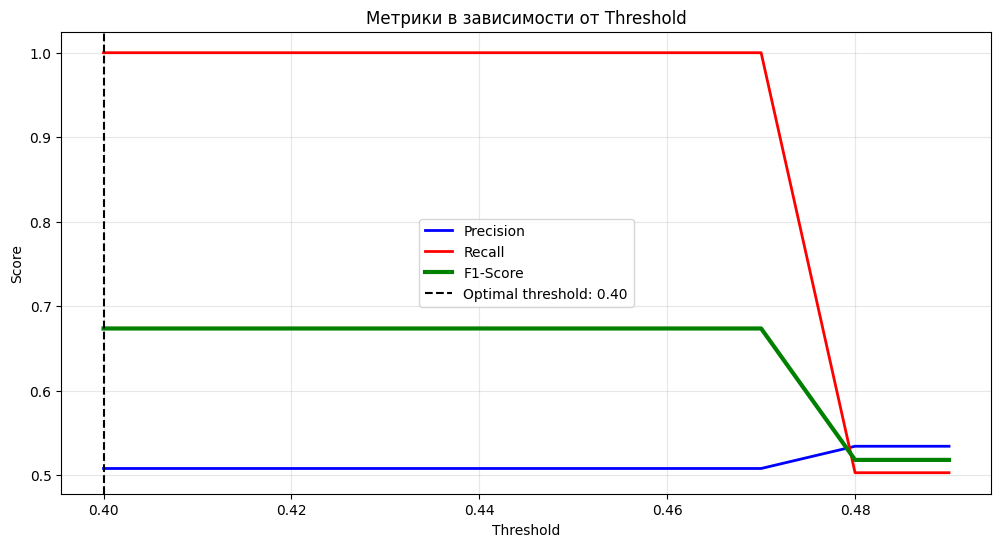

Оптимальный threshold: 0.40
Метрики при оптимальном threshold:
  Precision: 0.508
  Recall: 1.000
  F1-Score: 0.674


In [285]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

# Предположим, у вас есть предсказания модели (probabilities)
y_pred_proba = tree_best.predict_proba(X_test)[:, 1]  # вероятности класса 1
y_true = y_test

# Перебираем threshold от 0.1 до 0.9
thresholds = np.arange(0.4, 0.5, 0.01)
precisions = []
recalls = []
f1_scores = []

for threshold in thresholds:
    # Бинаризуем предсказания по threshold
    y_pred = (y_pred_proba >= threshold).astype(int)
    
    # Считаем метрики
    precisions.append(precision_score(y_true, y_pred, zero_division=0))
    recalls.append(recall_score(y_true, y_pred))
    f1_scores.append(f1_score(y_true, y_pred))

# Строим график
plt.figure(figsize=(12, 6))
plt.plot(thresholds, precisions, 'b-', label='Precision', linewidth=2)
plt.plot(thresholds, recalls, 'r-', label='Recall', linewidth=2)
plt.plot(thresholds, f1_scores, 'g-', label='F1-Score', linewidth=3)

# Находим оптимальный threshold по F1
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]

plt.axvline(x=optimal_threshold, color='black', linestyle='--', 
            label=f'Optimal threshold: {optimal_threshold:.2f}')

plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Метрики в зависимости от Threshold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Оптимальный threshold: {optimal_threshold:.2f}")
print(f"Метрики при оптимальном threshold:")
print(f"  Precision: {precisions[optimal_idx]:.3f}")
print(f"  Recall: {recalls[optimal_idx]:.3f}")
print(f"  F1-Score: {f1_scores[optimal_idx]:.3f}")

Случайный лес

In [278]:
from sklearn.ensemble import RandomForestClassifier
random_forest = RandomForestClassifier()
random_forest.fit(X_train, y_train)
y_pred_random_forest = random_forest.predict(X_test)
print(metrics.classification_report(y_test, y_pred_random_forest))

              precision    recall  f1-score   support

           0       0.47      0.51      0.49       347
           1       0.48      0.45      0.46       358

    accuracy                           0.48       705
   macro avg       0.48      0.48      0.48       705
weighted avg       0.48      0.48      0.48       705



In [284]:
def objective_rf(trial):
    n_estimators = trial.suggest_int('n_estimators', 50, 500)
    criterion = trial.suggest_categorical('criterion', ['gini', 'entropy'])
    max_depth = trial.suggest_int('max_depth', 3, 50)
    
    min_samples_split = trial.suggest_int('min_samples_split', 2, 30)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 30)
    min_weight_fraction_leaf = trial.suggest_float('min_weight_fraction_leaf', 0.0, 0.5)
    max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2', None])
    bootstrap = trial.suggest_categorical('bootstrap', [True, False])
    max_samples = trial.suggest_float('max_samples', 0.5, 1.0) if bootstrap else None
    
    model = RandomForestClassifier(
        random_state=42,
        n_estimators=n_estimators,
        criterion=criterion,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        min_weight_fraction_leaf=min_weight_fraction_leaf,
        max_features=max_features,
        bootstrap=bootstrap,
        max_samples=max_samples,
        n_jobs=-1 
    )
    
    scores = cross_val_score(model, X=X_train, y=y_train, cv=kf, scoring='f1', n_jobs=-1)
    score = np.mean(scores)
    return score

study_rf = optuna.create_study(study_name='RandomForestClassifier', direction='maximize')
study_rf.optimize(objective_rf, n_trials=30, show_progress_bar=True)

[I 2025-11-24 22:54:16,698] A new study created in memory with name: RandomForestClassifier


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2025-11-24 22:54:19,338] Trial 0 finished with value: 0.50400837107176 and parameters: {'n_estimators': 473, 'criterion': 'gini', 'max_depth': 49, 'min_samples_split': 6, 'min_samples_leaf': 7, 'min_weight_fraction_leaf': 0.06696136620896653, 'max_features': 'sqrt', 'bootstrap': True, 'max_samples': 0.666446587033599}. Best is trial 0 with value: 0.50400837107176.
[I 2025-11-24 22:54:20,369] Trial 1 finished with value: 0.45891948149008827 and parameters: {'n_estimators': 131, 'criterion': 'entropy', 'max_depth': 16, 'min_samples_split': 4, 'min_samples_leaf': 15, 'min_weight_fraction_leaf': 0.4791945338562952, 'max_features': None, 'bootstrap': True, 'max_samples': 0.8040743703269314}. Best is trial 0 with value: 0.50400837107176.
[I 2025-11-24 22:54:22,379] Trial 2 finished with value: 0.506537755026478 and parameters: {'n_estimators': 348, 'criterion': 'gini', 'max_depth': 20, 'min_samples_split': 5, 'min_samples_leaf': 2, 'min_weight_fraction_leaf': 0.1394071363434461, 'max_feat

KeyboardInterrupt: 

In [ ]:
best_params_random_forest= study_rf.best_params
print(best_params_random_forest)
random_forest_best = RandomForestClassifier(**best_params_random_forest)
random_forest_best.fit(X_train, y_train)
y_pred_random_forest_random_best = random_forest_best.predict(X_test)
print(metrics.classification_report(y_test, y_pred_random_forest_random_best))

{'n_estimators': 50, 'criterion': 'entropy', 'max_depth': 33, 'min_samples_split': 11, 'min_samples_leaf': 9, 'min_weight_fraction_leaf': 0.15221671160048045, 'max_features': 'log2', 'bootstrap': True, 'max_samples': 0.968737608997573}
              precision    recall  f1-score   support

           0       0.51      0.52      0.52       347
           1       0.53      0.52      0.53       358

    accuracy                           0.52       705
   macro avg       0.52      0.52      0.52       705
weighted avg       0.52      0.52      0.52       705



<Axes: >

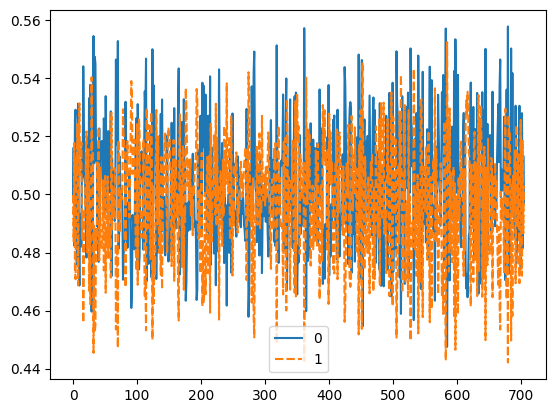

In [ ]:
y_pred_random_forest_random_best_proba = random_forest_best.predict_proba(X_test)
sns.lineplot(y_pred_random_forest_random_best_proba)

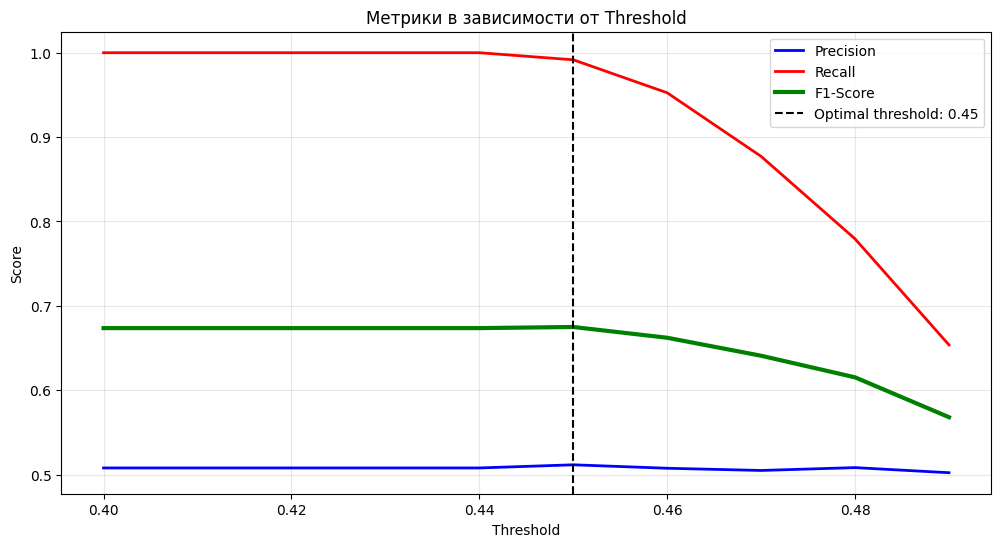

Оптимальный threshold: 0.45
Метрики при оптимальном threshold:
  Precision: 0.512
  Recall: 0.992
  F1-Score: 0.675


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

# Предположим, у вас есть предсказания модели (probabilities)
y_pred_proba = random_forest_best.predict_proba(X_test)[:, 1]  # вероятности класса 1
y_true = y_test

# Перебираем threshold от 0.1 до 0.9
thresholds = np.arange(0.4, 0.5, 0.01)
precisions = []
recalls = []
f1_scores = []

for threshold in thresholds:
    # Бинаризуем предсказания по threshold
    y_pred = (y_pred_proba >= threshold).astype(int)
    
    # Считаем метрики
    precisions.append(precision_score(y_true, y_pred, zero_division=0))
    recalls.append(recall_score(y_true, y_pred))
    f1_scores.append(f1_score(y_true, y_pred))

# Строим график
plt.figure(figsize=(12, 6))
plt.plot(thresholds, precisions, 'b-', label='Precision', linewidth=2)
plt.plot(thresholds, recalls, 'r-', label='Recall', linewidth=2)
plt.plot(thresholds, f1_scores, 'g-', label='F1-Score', linewidth=3)

# Находим оптимальный threshold по F1
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]

plt.axvline(x=optimal_threshold, color='black', linestyle='--', 
            label=f'Optimal threshold: {optimal_threshold:.2f}')

plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Метрики в зависимости от Threshold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Оптимальный threshold: {optimal_threshold:.2f}")
print(f"Метрики при оптимальном threshold:")
print(f"  Precision: {precisions[optimal_idx]:.3f}")
print(f"  Recall: {recalls[optimal_idx]:.3f}")
print(f"  F1-Score: {f1_scores[optimal_idx]:.3f}")

In [302]:
def quick_diagnostic(data, target):
    print("=== ДИАГНОСТИКА ===")
    
    # 1. Баланс классов
    print(f"Баланс классов: {target.value_counts(normalize=True)}")
    
    # 2. Autocorrelation
    from statsmodels.tsa.stattools import acf
    autocorr = acf(target, nlags=10)
    print(f"Автокорреляция target (lag1): {autocorr[1]:.3f}")
    
    # 3. Feature importance (случайный лес)
    from sklearn.ensemble import RandomForestClassifier
    rf = RandomForestClassifier(n_estimators=50)
    rf.fit(data.drop(columns=['target']), target)
    print("Важность признаков (топ-5):")
    importances = pd.Series(rf.feature_importances_, index=data.columns[:-1])
    print(importances.sort_values(ascending=False).head(5))


In [295]:
# Если X и y - это отдельные Series/DataFrame
X = pd.DataFrame(X)  # если X не DataFrame
y = pd.Series(y)     # если y не Series

# Создаем объединенный DataFrame
combined_df = X.copy()
combined_df['target'] = y
combined_df.drop('time_N', axis=1, inplace=True)

In [296]:
combined_df

,months_N,days_N,hours_N,months_N-1,days_N-1,hours_N-1,ratio_body_to_all_candle_N,ratio_body_to_all_candle_N-1,ratio_up_shadow_to_body_N,ratio_up_shadow_to_body_N-1,...,diff_SMA_30_N_1,diff_SMA_50_N,diff_SMA_50_N_1,diff_SMA_100_N,diff_SMA_100_N_1,diff_SMA_150_N,diff_SMA_150_N_1,diff_SMA_200_N,diff_SMA_200_N_1,target
229,1,21,17,1,21,16,0.756757,0.080000,0.142857,8.500000,...,-0.203193,-1.462820,-3.157112,-7.898277,-9.483440,-11.425711,-12.941455,-14.725066,-16.163927,1
428,1,30,22,1,30,21,0.785714,0.214286,0.090909,1.666667,...,0.526883,0.485761,-0.066662,0.151295,-0.380323,1.420366,0.958474,1.465784,0.915391,0
480,2,3,21,2,3,20,0.363636,0.071429,1.750000,12.000000,...,-2.151813,-2.428228,-2.779005,-5.330454,-5.611229,-6.534319,-6.766116,-6.222841,-6.390661,1
544,2,6,12,2,6,12,0.777778,0.357143,0.142857,0.000000,...,-0.835119,-0.703838,-1.137701,-2.089152,-2.503192,-4.173120,-4.615708,-5.876225,-6.295318,1
548,2,6,14,2,6,14,0.538462,0.333333,0.714286,1.500000,...,-0.483261,-0.289377,-0.704299,-1.604817,-2.038022,-3.601901,-4.040787,-5.398145,-5.813838,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
116424,6,18,16,6,18,16,0.601504,0.482517,0.137500,0.014493,...,-2.868017,-3.437820,-3.783875,-3.976449,-4.272492,-4.167966,-4.446013,-4.299771,-4.580444,0
116476,6,20,12,6,20,12,0.750000,0.080460,0.190476,0.285714,...,-0.773904,-0.767828,-0.922650,-2.571392,-2.762829,-3.584786,-3.756621,-4.105293,-4.262094,1
116534,6,24,11,6,24,11,0.350000,0.070423,0.685714,10.200000,...,-0.148268,-0.060795,-0.181209,-0.735873,-0.864266,-1.947074,-2.104042,-3.085958,-3.225929,1
116573,6,25,16,6,25,15,0.672414,0.480769,0.333333,0.600000,...,0.482395,0.877253,0.786800,1.037759,0.929358,0.610122,0.493185,-0.587935,-0.728440,1


In [303]:
quick_diagnostic(combined_df, combined_df['target'])

=== ДИАГНОСТИКА ===
Баланс классов: target
0    0.500243
1    0.499757
Name: proportion, dtype: float64
Автокорреляция target (lag1): 0.005
Важность признаков (топ-5):
low_shadow_ATR_N_1            0.031064
ratio_body_to_all_candle_N    0.031003
diff_SMA_5_N_1                0.030558
full_candle_ATR_N             0.030049
body_ATR_N-1                  0.029270
dtype: float64


In [306]:
pip install xgboost


   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/72.0 MB 320.0 kB/s eta 0:03:45
   ---------------------------------------- 0.1/72.0 MB 518.5 kB/s eta 0:02:19
   ---------------------------------------- 0.1/72.0 MB 1.1 MB/s eta 0:01:08
   ---------------------------------------- 0.3/72.0 MB 1.7 MB/s eta 0:00:43
   ---------------------------------------- 0.4/72.0 MB 2.1 MB/s eta 0:00:35
   ---------------------------------------- 0.4/72.0 MB 2.1 MB/s eta 0:00:35
   ---------------------------------------- 0.4/72.0 MB 2.1 MB/s eta 0:00:35
   ---------------------------------------- 0.4/72.0 MB 2.1 MB/s eta 0:00:35
   ---------------------------------------- 0.6/72.0 MB 1.5 MB/s eta 0:00:49
   ---------------------------------------- 0.7/72.0 MB 1.7 MB/s eta 0:00:42
   ---------------------------------------- 0.8/72.0 MB 1.6 MB/s eta 0:00:45
   ---------------------------------------- 0.8/72.0 MB 1.5 MB/s eta 0:00:47
 

In [305]:
import xgboost as xgb

ModuleNotFoundError: No module named 'xgboost'

In [310]:
import xgboost as xgb
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import numpy as np


print("=== XGBOOST МОДЕЛЬ ===")
print(f"Размер train: {X_train.shape}")
print(f"Размер test: {X_test.shape}")

# Создаем и обучаем модель
model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=16,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

# Кросс-валидация
print("\n=== КРОСС-ВАЛИДАЦИЯ ===")
cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='f1')
print(f"F1-score на кросс-валидации: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")
print(f"Все fold-ы: {[f'{score:.4f}' for score in cv_scores]}")

# Обучаем на полном train
model.fit(X_train, y_train)

# Предсказания
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Результаты
print("\n=== РЕЗУЛЬТАТЫ НА ТЕСТЕ ===")
print(f"F1-score: {f1_score(y_test, y_pred):.4f}")
print(f"Accuracy: {model.score(X_test, y_test):.4f}")

print("\n=== ДЕТАЛЬНЫЙ ОТЧЕТ ===")
print(classification_report(y_test, y_pred))

print("\n=== MATRIXA ОШИБОК ===")
print(confusion_matrix(y_test, y_pred))

# Важность признаков

# ROC-AUC
from sklearn.metrics import roc_auc_score
auc = roc_auc_score(y_test, y_pred_proba)
print(f"\nROC-AUC: {auc:.4f}")

# Сравнение с baseline
from sklearn.dummy import DummyClassifier
dummy = DummyClassifier(strategy='stratified')
dummy.fit(X_train, y_train)
dummy_score = dummy.score(X_test, y_test)
print(f"\nBaseline (random): {dummy_score:.4f}")
print(f"Улучшение над baseline: {model.score(X_test, y_test) - dummy_score:.4f}")

=== XGBOOST МОДЕЛЬ ===
Размер train: (3417, 39)
Размер test: (705, 39)

=== КРОСС-ВАЛИДАЦИЯ ===
F1-score на кросс-валидации: 0.4926 (+/- 0.0225)
Все fold-ы: ['0.5043', '0.4722', '0.5014', '0.4933', '0.4918']

=== РЕЗУЛЬТАТЫ НА ТЕСТЕ ===
F1-score: 0.5076
Accuracy: 0.4965

=== ДЕТАЛЬНЫЙ ОТЧЕТ ===
              precision    recall  f1-score   support

           0       0.49      0.48      0.48       347
           1       0.50      0.51      0.51       358

    accuracy                           0.50       705
   macro avg       0.50      0.50      0.50       705
weighted avg       0.50      0.50      0.50       705


=== MATRIXA ОШИБОК ===
[[167 180]
 [175 183]]

ROC-AUC: 0.4777

Baseline (random): 0.5319
Улучшение над baseline: -0.0355
